In [2]:
# Import required libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import multivariate_normal
import time

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import GaussianNB

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix
)

import warnings
warnings.filterwarnings('ignore')
plt.style.use('seaborn-v0_8-darkgrid')
np.random.seed(42)

print("Libraries imported successfully!")

Libraries imported successfully!


In [14]:
# Helper Functions  


def load_data(train_path, val_path, test_path):
    
    # Load datasets
    train_df = pd.read_csv(train_path)
    val_df = pd.read_csv(val_path)
    test_df = pd.read_csv(test_path)
    
    # Separate features and target
    X_train = train_df.drop('Activity', axis=1).values
    y_train = train_df['Activity'].values
    
    X_val = val_df.drop('Activity', axis=1).values
    y_val = val_df['Activity'].values
    
    X_test = test_df.drop('Activity', axis=1).values
    y_test = test_df['Activity'].values
    
    return X_train, y_train, X_val, y_val, X_test, y_test


def evaluate_classifier(y_true, y_pred, dataset_name, split_name):
    """
    Evaluate classifier performance and return metrics.
    
    Args:
        y_true: True labels
        y_pred: Predicted labels
        dataset_name: Name of the dataset variant
        split_name: 'Validation' or 'Test'
    
    Returns:
        Dictionary containing all metrics
    """
    # Calculate metrics
    accuracy = accuracy_score(y_true, y_pred)
    precision_macro = precision_score(y_true, y_pred, average='macro', zero_division=0)
    precision_micro = precision_score(y_true, y_pred, average='micro', zero_division=0)
    recall_macro = recall_score(y_true, y_pred, average='macro', zero_division=0)
    recall_micro = recall_score(y_true, y_pred, average='micro', zero_division=0)
    f1_macro = f1_score(y_true, y_pred, average='macro', zero_division=0)
    f1_micro = f1_score(y_true, y_pred, average='micro', zero_division=0)
    
    metrics = {
        'Dataset': dataset_name,
        'Split': split_name,
        'Accuracy': accuracy,
        'Precision (Macro)': precision_macro,
        'Precision (Micro)': precision_micro,
        'Recall (Macro)': recall_macro,
        'Recall (Micro)': recall_micro,
        'F1-Score (Macro)': f1_macro,
        'F1-Score (Micro)': f1_micro
    }
    
    return metrics


def plot_confusion_matrix(y_true, y_pred, title, classes):
    """
    Plot confusion matrix as a heatmap.
    
    Args:
        y_true: True labels
        y_pred: Predicted labels
        title: Title for the plot
        classes: List of class names
    """
    cm = confusion_matrix(y_true, y_pred)
    
    plt.figure(figsize=(10, 8))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
                xticklabels=classes, yticklabels=classes,
                cbar_kws={'label': 'Count'})
    plt.title(title, fontsize=14, fontweight='bold')
    plt.ylabel('True Label', fontsize=12)
    plt.xlabel('Predicted Label', fontsize=12)
    plt.tight_layout()
    plt.show()
    
    return cm


print("Helper functions defined successfully!")

Helper functions defined successfully!


In [15]:
#Bayes Classifier using multivariate Gaussian distribution.

class BayesClassifier:
    
    def fit(self, X, y):
        self.cls = np.unique(y)
        self.cls_mean = {}
        self.cls_cov = {}
        self.cls_prior = {}

        for i in self.cls:
            X_i = X[y == i]
            self.cls_mean[i] = np.mean(X_i, axis=0)
            self.cls_cov[i] = np.cov(X_i, rowvar=False)
            self.cls_prior[i] = X_i.shape[0] / X.shape[0]

    def predict(self, X):
        X = np.array(X)
        posteriors = []

        for i in self.cls:
            # Likelihood P(X | class)
            likelihood = multivariate_normal.pdf(
                X,
                mean=self.cls_mean[i],
                cov=self.cls_cov[i],
                allow_singular=True
            )

            # Prior P(class)
            prior = self.cls_prior[i]

            # Posterior numerator: P(X|C) * P(C)
            posterior = likelihood * prior
            posteriors.append(posterior)

        # Convert to array shape (n_classes, n_samples)
        posteriors = np.array(posteriors)

        # Pick class with highest posterior
        predictions = self.cls[np.argmax(posteriors, axis=0)]

        return predictions
            

In [16]:
def train_and_evaluate_bayes(train_path, val_path, test_path, dataset_name):
    """
    Train Bayes classifier and evaluate on validation and test sets.
    
    Returns:
        (validation_metrics, test_metrics, trained_model)
    """

    print("\n" + "="*80)
    print(f"Training Bayes Classifier on {dataset_name}")
    print("="*80)

    # Load data
    X_train, y_train, X_val, y_val, X_test, y_test = load_data(
        train_path, val_path, test_path
    )

    print(f"Training samples   : {X_train.shape[0]}")
    print(f"Validation samples : {X_val.shape[0]}")
    print(f"Test samples       : {X_test.shape[0]}")
    print(f"Number of features : {X_train.shape[1]}")

    # Initialize and train classifier
    bayes = BayesClassifier()
    bayes.fit(X_train, y_train)

    print("\nModel training completed!")

    # ------------------ VALIDATION ------------------
    print("\nPredicting on validation set...")
    y_val_pred = np.array(bayes.predict(X_val))
    val_metrics = evaluate_classifier(
        y_val, y_val_pred, dataset_name, "Validation"
    )

    # ------------------ TEST ------------------
    print("\nPredicting on test set...")
    y_test_pred = np.array(bayes.predict(X_test))
    test_metrics = evaluate_classifier(
        y_test, y_test_pred, dataset_name, "Test"
    )

    # Get class labels
    classes = bayes.cls   # <-- fixed (was bayes.classes)

    # ------------------ CONFUSION MATRICES ------------------
    print("\n--- Validation Set Confusion Matrix ---")
    plot_confusion_matrix(
        y_val,
        y_val_pred,
        f"Bayes Classifier - {dataset_name} (Validation)",
        classes
    )

    print("\n--- Test Set Confusion Matrix ---")
    plot_confusion_matrix(
        y_test,
        y_test_pred,
        f"Bayes Classifier - {dataset_name} (Test)",
        classes
    )

    # ------------------ METRICS ------------------
    print("\n--- Validation Set Metrics ---")
    for key, value in val_metrics.items():
        if key not in ["Dataset", "Split"]:
            print(f"{key}: {value:.4f}")

    print("\n--- Test Set Metrics ---")
    for key, value in test_metrics.items():
        if key not in ["Dataset", "Split"]:
            print(f"{key}: {value:.4f}")

    return val_metrics, test_metrics, bayes



Training Bayes Classifier on Original Data
Training samples   : 6179
Validation samples : 2060
Test samples       : 2060
Number of features : 561

Model training completed!

Predicting on validation set...

Predicting on test set...

--- Validation Set Confusion Matrix ---


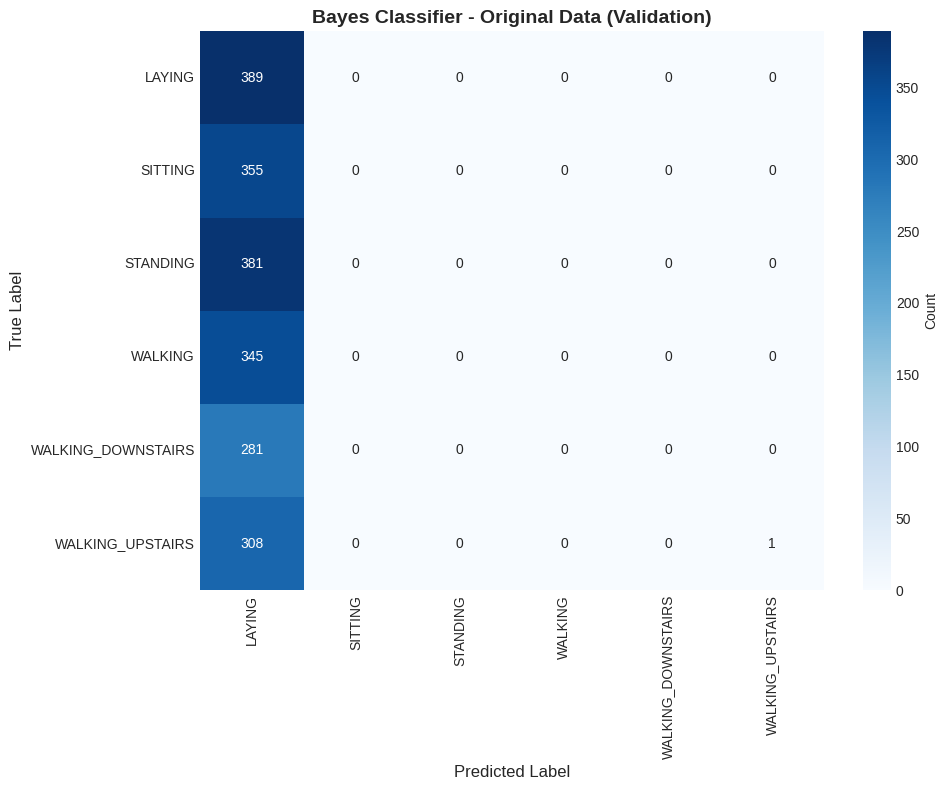


--- Test Set Confusion Matrix ---


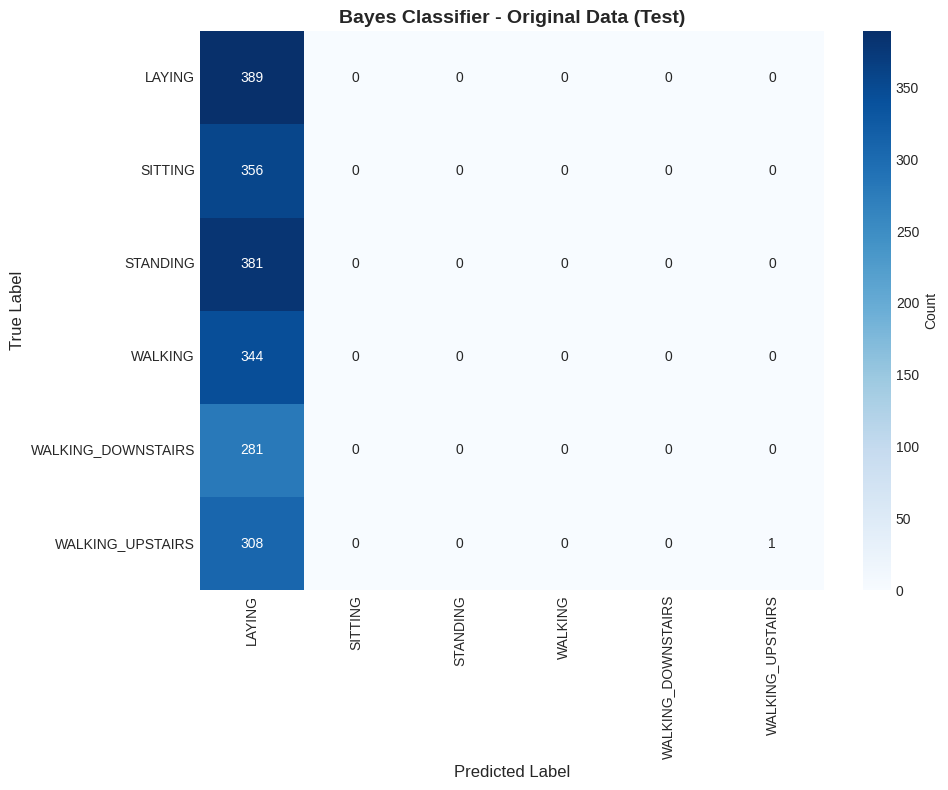


--- Validation Set Metrics ---
Accuracy: 0.1893
Precision (Macro): 0.1982
Precision (Micro): 0.1893
Recall (Macro): 0.1672
Recall (Micro): 0.1893
F1-Score (Macro): 0.0540
F1-Score (Micro): 0.1893

--- Test Set Metrics ---
Accuracy: 0.1893
Precision (Macro): 0.1982
Precision (Micro): 0.1893
Recall (Macro): 0.1672
Recall (Micro): 0.1893
F1-Score (Macro): 0.0540
F1-Score (Micro): 0.1893


In [17]:
# 1.Bayes on Original Data

bayes_original_val, bayes_original_test, bayes_original_model = train_and_evaluate_bayes(
    'Activity_Train.csv',
    'Activity_Validation.csv',
    'Activity_Test.csv',
    'Original Data'
)

In [18]:
# Naive Bayes Classifier 

def train_and_evaluate_naive_bayes(train_path, val_path, test_path, dataset_name):
    """
    Train Naive Bayes classifier and evaluate on validation and test sets.
    
    Args:
        train_path: Path to training data
        val_path: Path to validation data
        test_path: Path to test data
        dataset_name: Name of dataset variant
    
    Returns:
        Tuple of (validation_metrics, test_metrics, model)
    """
    print(f"\n{'='*80}")
    print(f"Training Naive Bayes on {dataset_name}")
    print(f"{'='*80}")
    
    # Load data
    X_train, y_train, X_val, y_val, X_test, y_test = load_data(train_path, val_path, test_path)
    
    print(f"Training samples: {X_train.shape[0]}")
    print(f"Validation samples: {X_val.shape[0]}")
    print(f"Test samples: {X_test.shape[0]}")
    print(f"Number of features: {X_train.shape[1]}")
    
    # Initialize and train Naive Bayes model
    naive_bayes = GaussianNB()
    naive_bayes.fit(X_train, y_train)
    print("\nModel training completed!")
    
    # Predict on validation set
    y_val_pred = naive_bayes.predict(X_val)
    val_metrics = evaluate_classifier(y_val, y_val_pred, dataset_name, 'Validation')
    
    # Predict on test set
    y_test_pred = naive_bayes.predict(X_test)
    test_metrics = evaluate_classifier(y_test, y_test_pred, dataset_name, 'Test')
    
    # Get class names
    classes = np.unique(y_train)
    
    # Plot confusion matrices
    print("\n--- Validation Set Confusion Matrix ---")
    plot_confusion_matrix(y_val, y_val_pred, 
                         f'Naive Bayes - {dataset_name} (Validation)', 
                         classes)
    
    print("\n--- Test Set Confusion Matrix ---")
    plot_confusion_matrix(y_test, y_test_pred, 
                         f'Naive Bayes - {dataset_name} (Test)', 
                         classes)
    
    # Print metrics
    print("\n--- Validation Set Metrics ---")
    for key, value in val_metrics.items():
        if key not in ['Dataset', 'Split']:
            print(f"{key}: {value:.4f}")
    
    print("\n--- Test Set Metrics ---")
    for key, value in test_metrics.items():
        if key not in ['Dataset', 'Split']:
            print(f"{key}: {value:.4f}")
    
    return val_metrics, test_metrics, naive_bayes


Training Naive Bayes on Original Data
Training samples: 6179
Validation samples: 2060
Test samples: 2060
Number of features: 561

Model training completed!

--- Validation Set Confusion Matrix ---


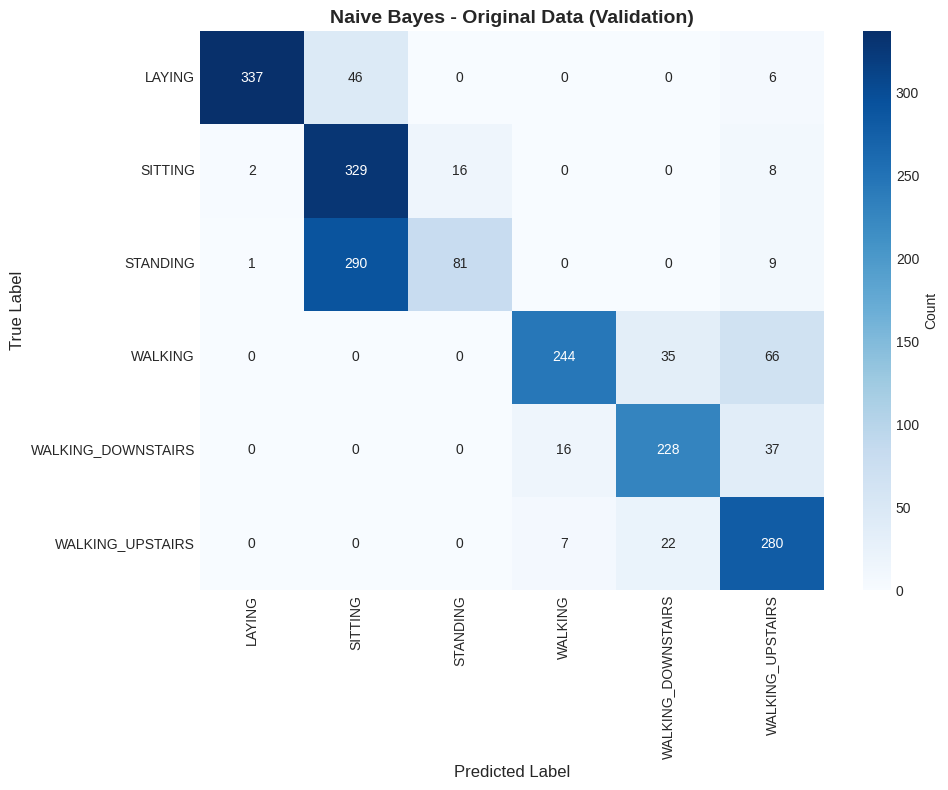


--- Test Set Confusion Matrix ---


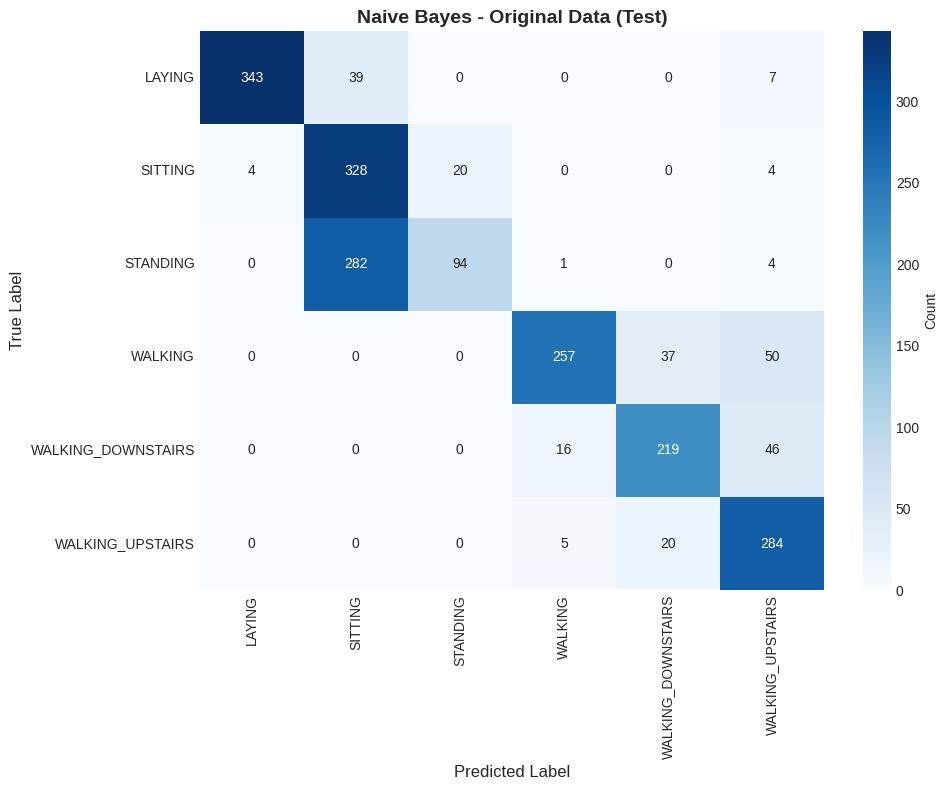


--- Validation Set Metrics ---
Accuracy: 0.7277
Precision (Macro): 0.7874
Precision (Micro): 0.7277
Recall (Macro): 0.7384
Recall (Micro): 0.7277
F1-Score (Macro): 0.7158
F1-Score (Micro): 0.7277

--- Test Set Metrics ---
Accuracy: 0.7403
Precision (Macro): 0.7920
Precision (Micro): 0.7403
Recall (Macro): 0.7492
Recall (Micro): 0.7403
F1-Score (Macro): 0.7305
F1-Score (Micro): 0.7403


In [21]:
# 1. Naive Bayes on Original Data

nb_original_val, nb_original_test, nb_original_model = train_and_evaluate_naive_bayes(
    'Activity_Train.csv',
    'Activity_Validation.csv',
    'Activity_Test.csv',
    'Original Data'
)


Training Naive Bayes on Standardized Data
Training samples: 6179
Validation samples: 2060
Test samples: 2060
Number of features: 561

Model training completed!

--- Validation Set Confusion Matrix ---


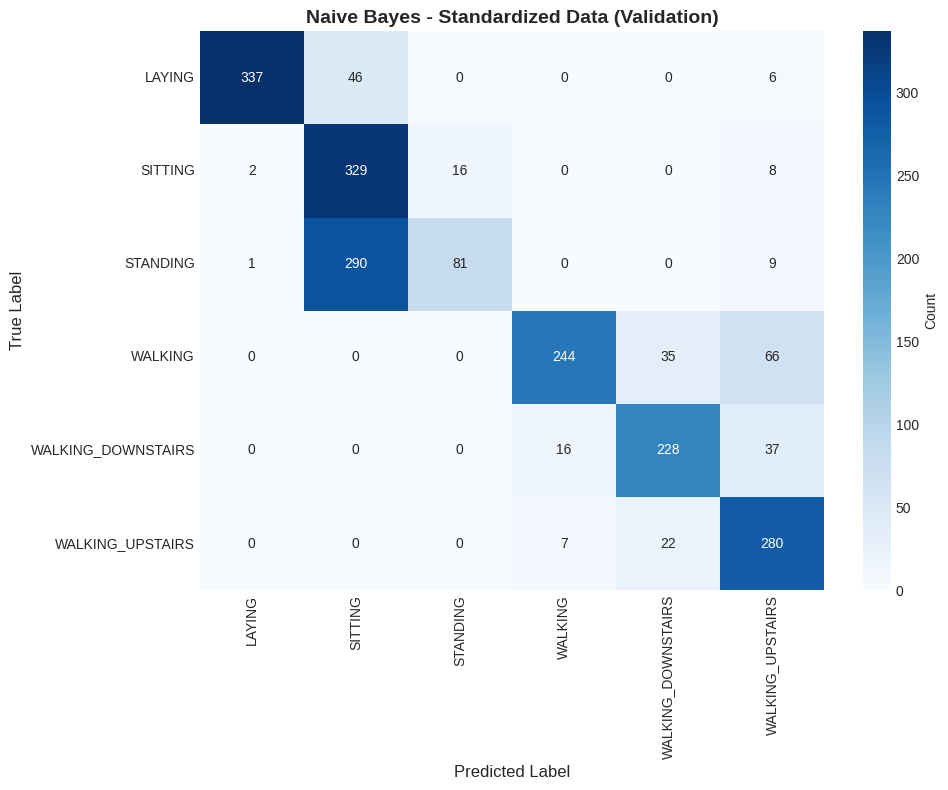


--- Test Set Confusion Matrix ---


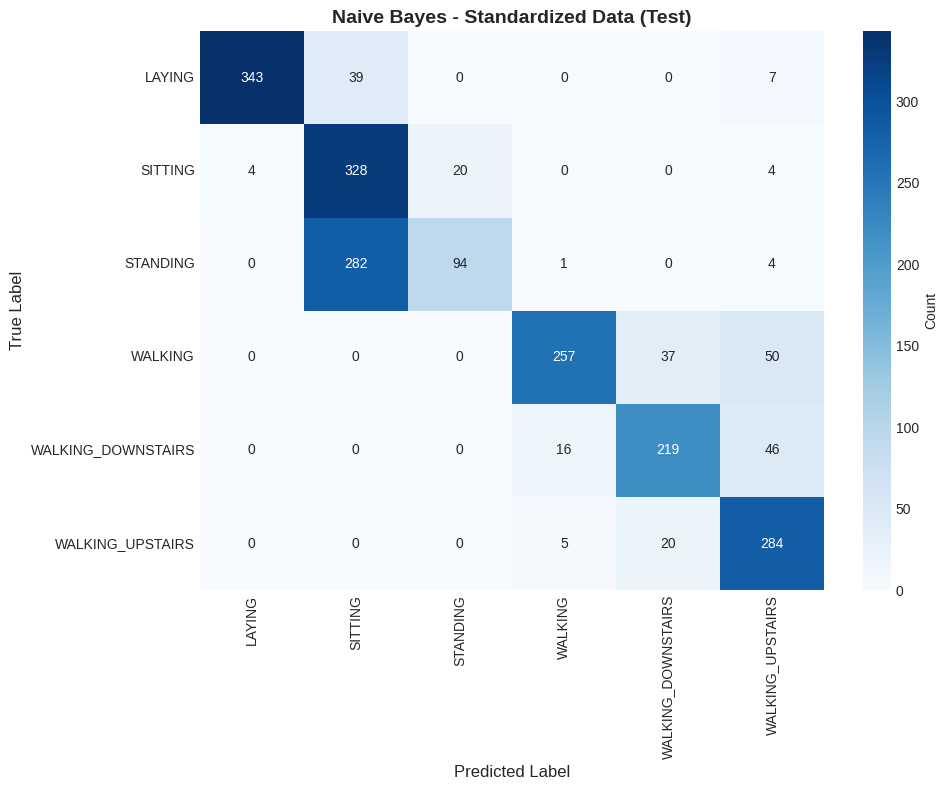


--- Validation Set Metrics ---
Accuracy: 0.7277
Precision (Macro): 0.7874
Precision (Micro): 0.7277
Recall (Macro): 0.7384
Recall (Micro): 0.7277
F1-Score (Macro): 0.7158
F1-Score (Micro): 0.7277

--- Test Set Metrics ---
Accuracy: 0.7403
Precision (Macro): 0.7920
Precision (Micro): 0.7403
Recall (Macro): 0.7492
Recall (Micro): 0.7403
F1-Score (Macro): 0.7305
F1-Score (Micro): 0.7403


In [22]:
# 2. Naive Bayes on Standardized Data

nb_scaled_val, nb_scaled_test, nb_scaled_model = train_and_evaluate_naive_bayes(
    'Activity_Scaled_Train.csv',
    'Activity_Scaled_Validation.csv',
    'Activity_Scaled_Test.csv',
    'Standardized Data'
)


Training Naive Bayes on PCA (All Components)
Training samples: 6179
Validation samples: 2060
Test samples: 2060
Number of features: 561

Model training completed!

--- Validation Set Confusion Matrix ---


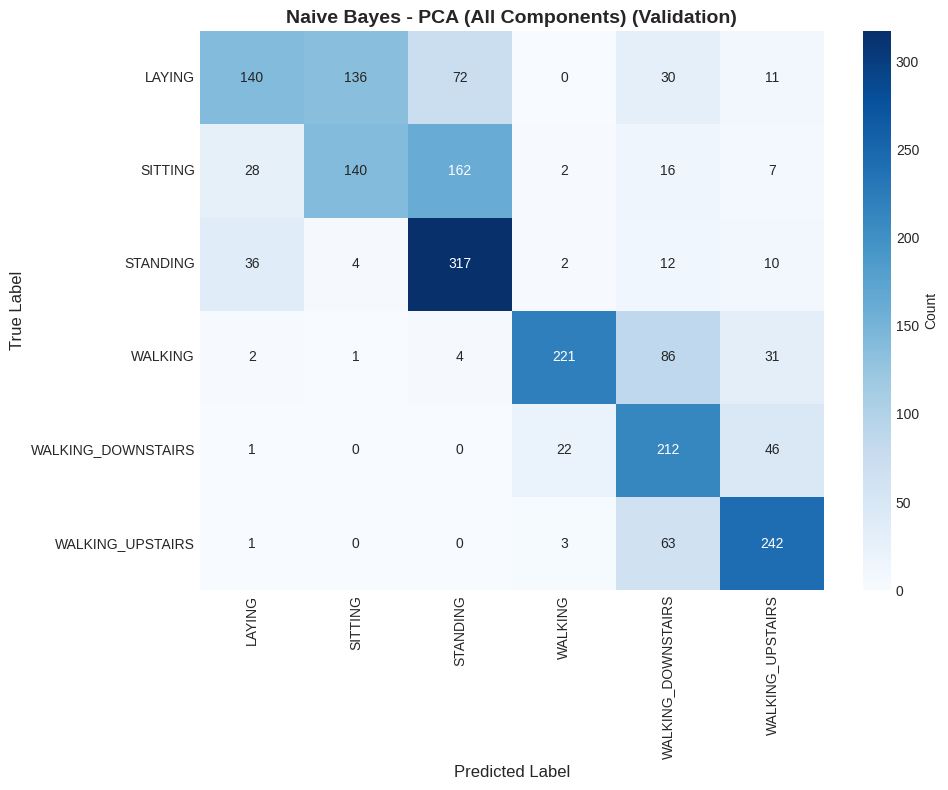


--- Test Set Confusion Matrix ---


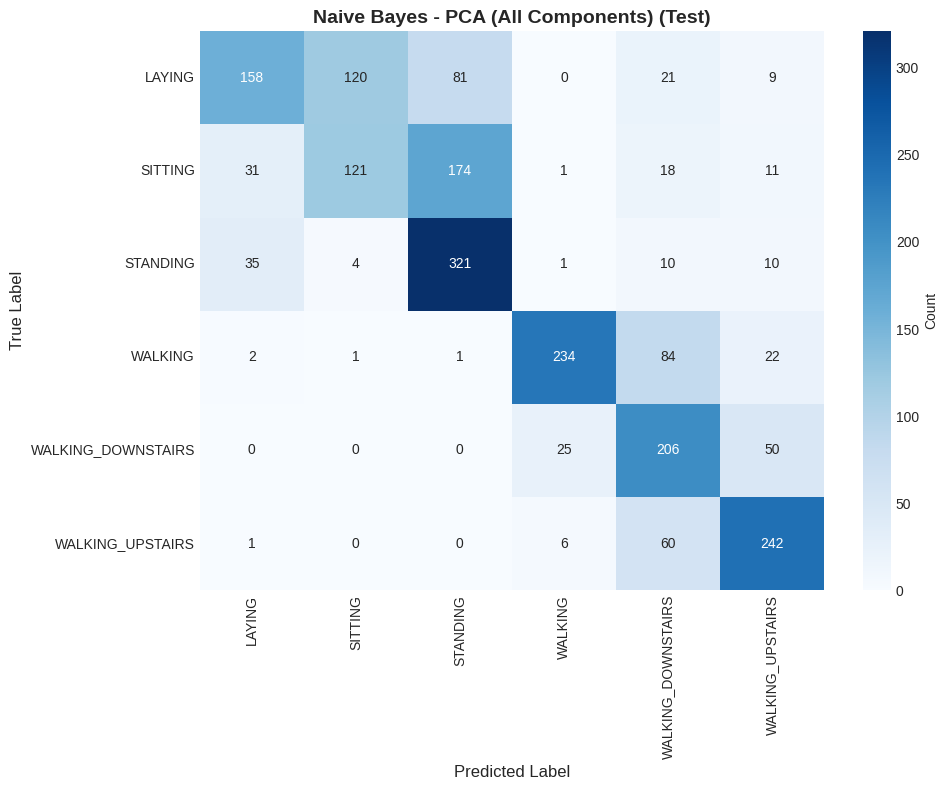


--- Validation Set Metrics ---
Accuracy: 0.6175
Precision (Macro): 0.6383
Precision (Micro): 0.6175
Recall (Macro): 0.6274
Recall (Micro): 0.6175
F1-Score (Macro): 0.6122
F1-Score (Micro): 0.6175

--- Test Set Metrics ---
Accuracy: 0.6223
Precision (Macro): 0.6401
Precision (Micro): 0.6223
Recall (Macro): 0.6308
Recall (Micro): 0.6223
F1-Score (Macro): 0.6164
F1-Score (Micro): 0.6223


In [23]:
# Naive Bayes on PCA All

nb_pca_all_val, nb_pca_all_test, nb_pca_all_model = train_and_evaluate_naive_bayes(
    'Activity_PCAAll_Train.csv',
    'Activity_PCAAll_Validation.csv',
    'Activity_PCAAll_Test.csv',
    'PCA (All Components)'
)


Training Naive Bayes on PCA (99% Variance)
Training samples: 6179
Validation samples: 2060
Test samples: 2060
Number of features: 156

Model training completed!

--- Validation Set Confusion Matrix ---


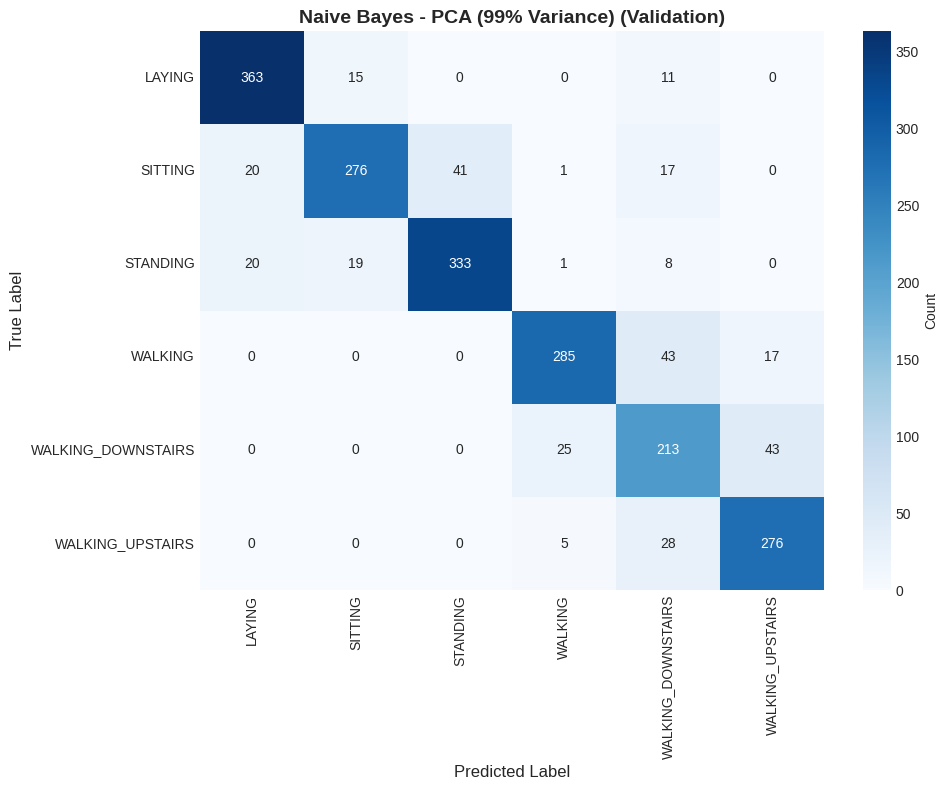


--- Test Set Confusion Matrix ---


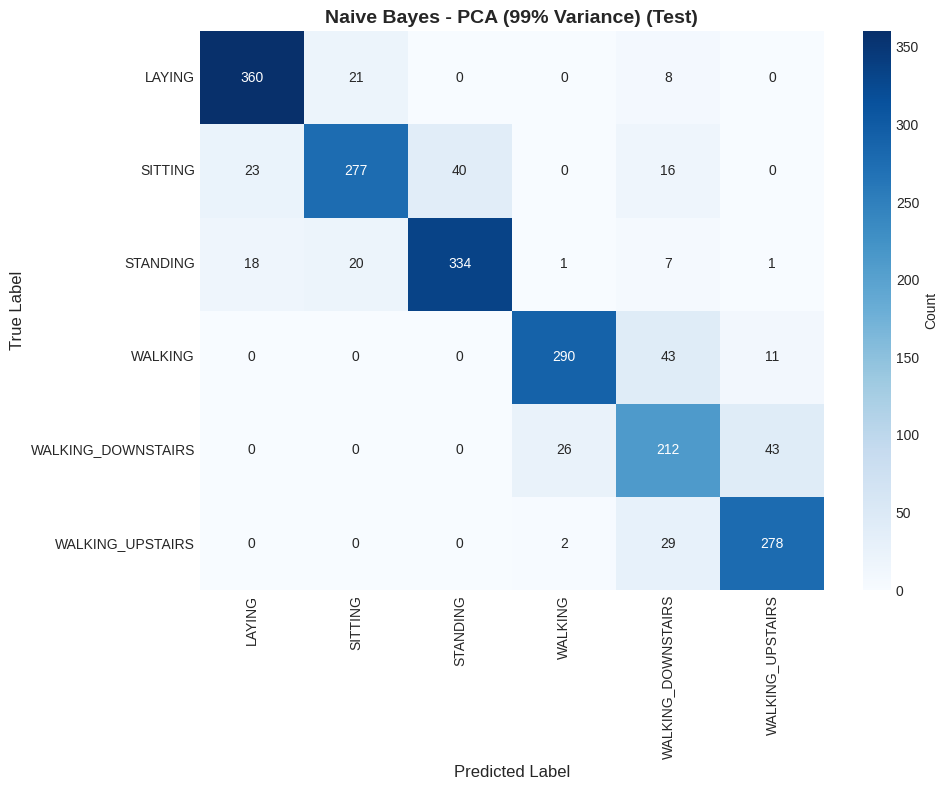


--- Validation Set Metrics ---
Accuracy: 0.8476
Precision (Macro): 0.8446
Precision (Micro): 0.8476
Recall (Macro): 0.8437
Recall (Micro): 0.8476
F1-Score (Macro): 0.8424
F1-Score (Micro): 0.8476

--- Test Set Metrics ---
Accuracy: 0.8500
Precision (Macro): 0.8465
Precision (Micro): 0.8500
Recall (Macro): 0.8462
Recall (Micro): 0.8500
F1-Score (Macro): 0.8451
F1-Score (Micro): 0.8500


In [25]:
# Naive bayes on PCA 99%

nb_pca99_val, nb_pca99_test, nb_pca99_model = train_and_evaluate_naive_bayes(
    'Activity_PCA99_Train.csv',
    'Activity_PCA99_Validation.csv',
    'Activity_PCA99_Test.csv',
    'PCA (99% Variance)'
)


Training Bayes Classifier on Standardized Data
Training samples   : 6179
Validation samples : 2060
Test samples       : 2060
Number of features : 561

Model training completed!

Predicting on validation set...

Predicting on test set...

--- Validation Set Confusion Matrix ---


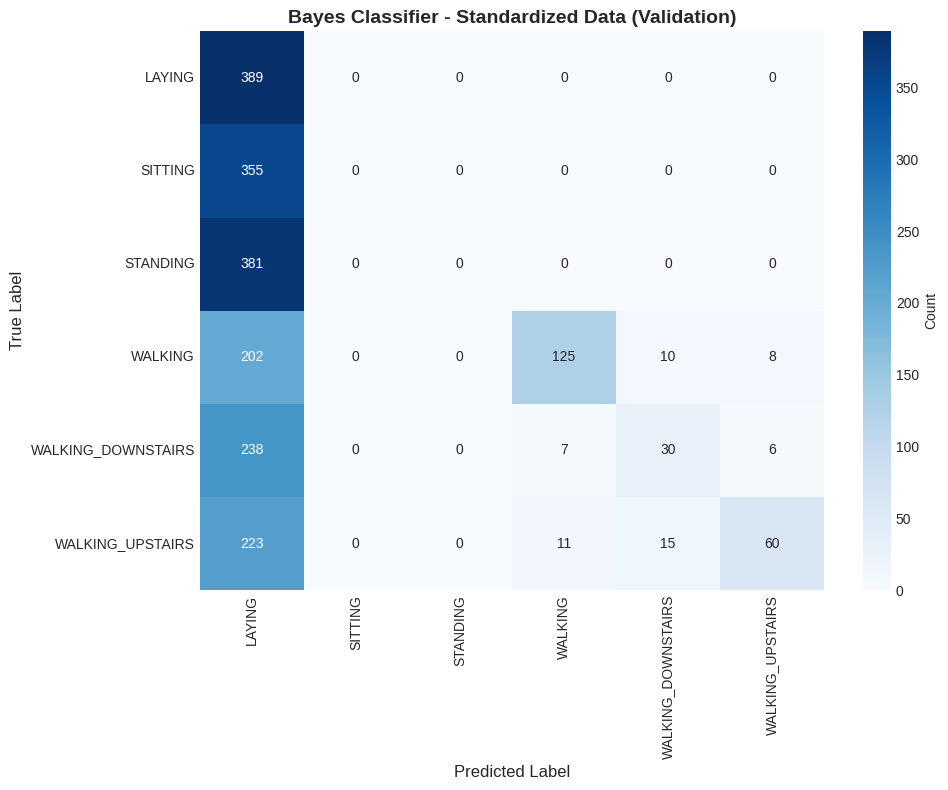


--- Test Set Confusion Matrix ---


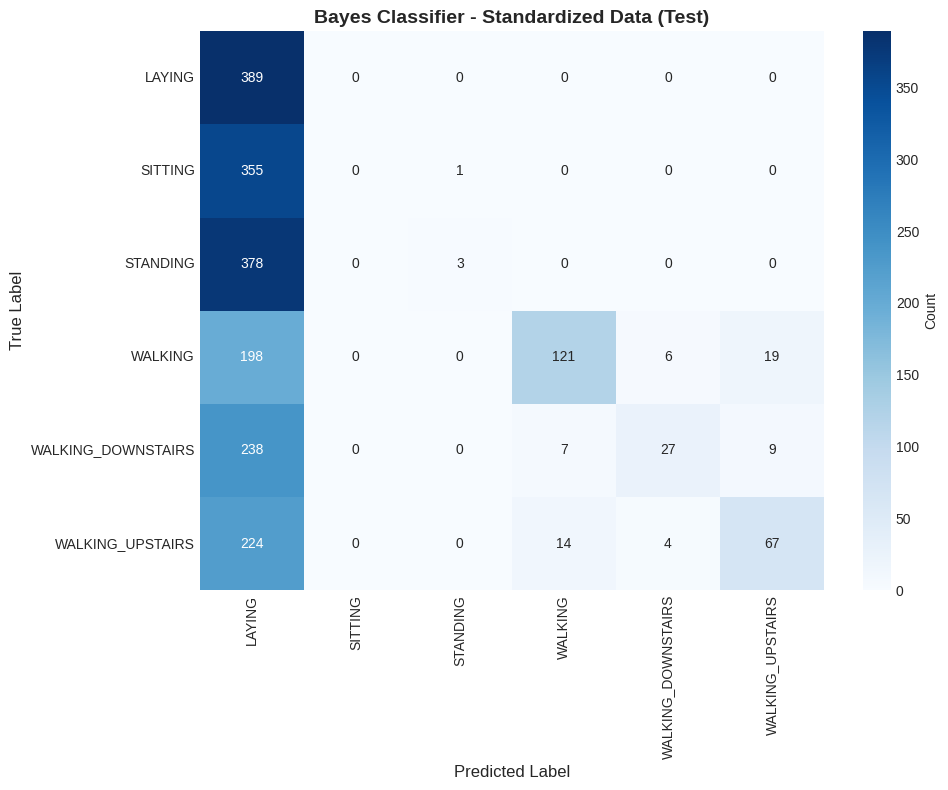


--- Validation Set Metrics ---
Accuracy: 0.2932
Precision (Macro): 0.4080
Precision (Micro): 0.2932
Recall (Macro): 0.2772
Recall (Micro): 0.2932
F1-Score (Macro): 0.2269
F1-Score (Micro): 0.2932

--- Test Set Metrics ---
Accuracy: 0.2947
Precision (Macro): 0.5426
Precision (Micro): 0.2947
Recall (Macro): 0.2788
Recall (Micro): 0.2947
F1-Score (Macro): 0.2289
F1-Score (Micro): 0.2947


In [26]:
# 2. Bayes Classifier on Standardized Data

bayes_scaled_val, bayes_scaled_test, bayes_scaled_model = train_and_evaluate_bayes(
    'Activity_Scaled_Train.csv',
    'Activity_Scaled_Validation.csv',
    'Activity_Scaled_Test.csv',
    'Standardized Data'
)


Training Bayes Classifier on PCA (All Components)
Training samples   : 6179
Validation samples : 2060
Test samples       : 2060
Number of features : 561

Model training completed!

Predicting on validation set...

Predicting on test set...

--- Validation Set Confusion Matrix ---


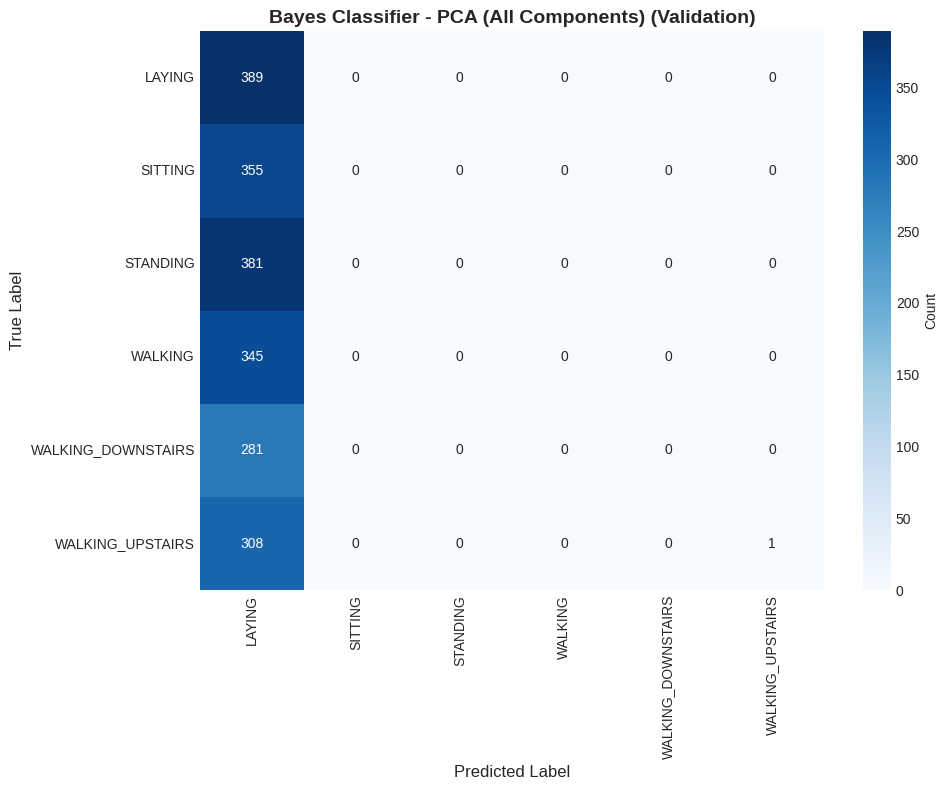


--- Test Set Confusion Matrix ---


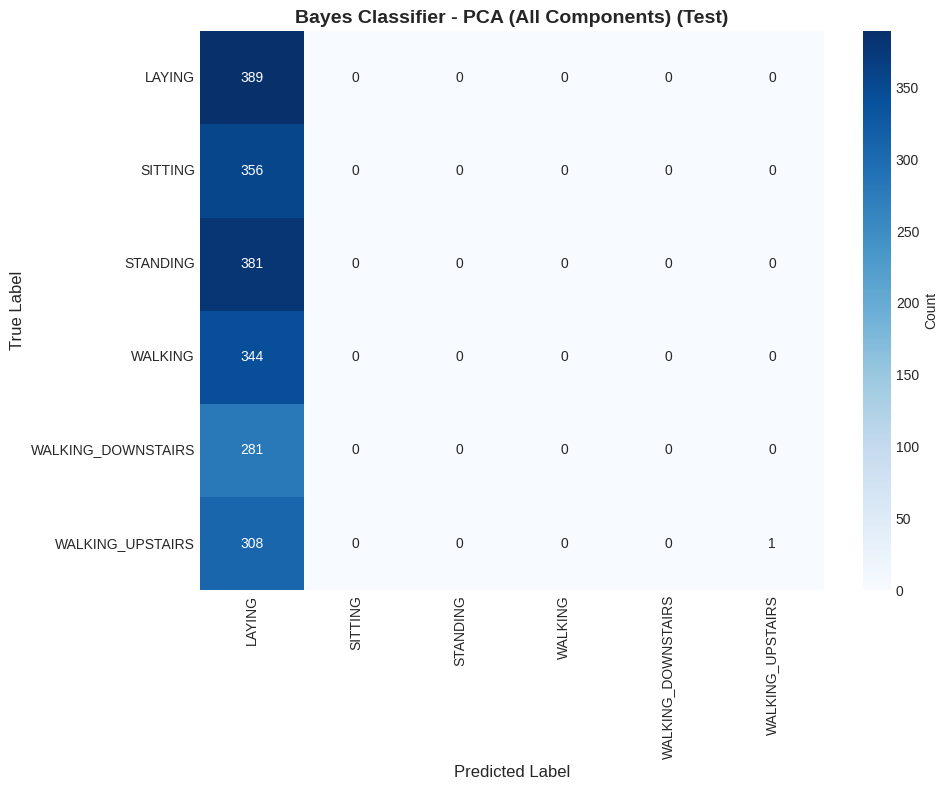


--- Validation Set Metrics ---
Accuracy: 0.1893
Precision (Macro): 0.1982
Precision (Micro): 0.1893
Recall (Macro): 0.1672
Recall (Micro): 0.1893
F1-Score (Macro): 0.0540
F1-Score (Micro): 0.1893

--- Test Set Metrics ---
Accuracy: 0.1893
Precision (Macro): 0.1982
Precision (Micro): 0.1893
Recall (Macro): 0.1672
Recall (Micro): 0.1893
F1-Score (Macro): 0.0540
F1-Score (Micro): 0.1893


In [28]:
# 3. Bayes Classifier on Standardized data 

bayes_pca_all_val, bayes_pca_all_test, bayes_pca_all_model = train_and_evaluate_bayes(
    'Activity_PCAAll_Train.csv',
    'Activity_PCAAll_Validation.csv',
    'Activity_PCAAll_Test.csv',
    'PCA (All Components)'
)


Training Bayes Classifier on PCA (99% Variance)
Training samples   : 6179
Validation samples : 2060
Test samples       : 2060
Number of features : 156

Model training completed!

Predicting on validation set...

Predicting on test set...

--- Validation Set Confusion Matrix ---


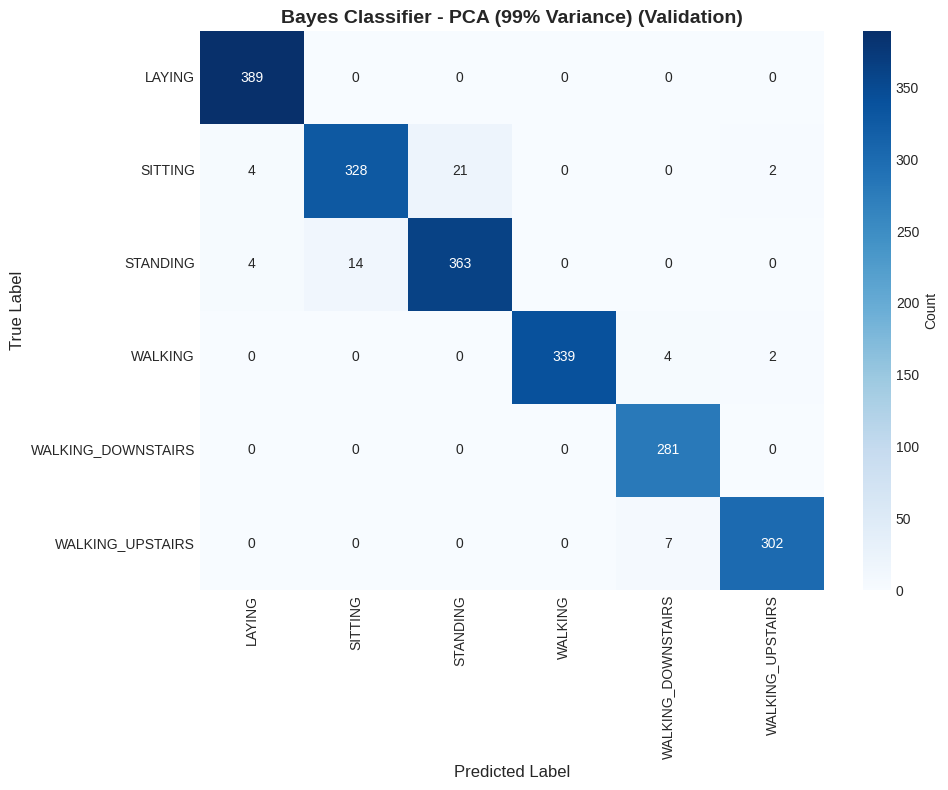


--- Test Set Confusion Matrix ---


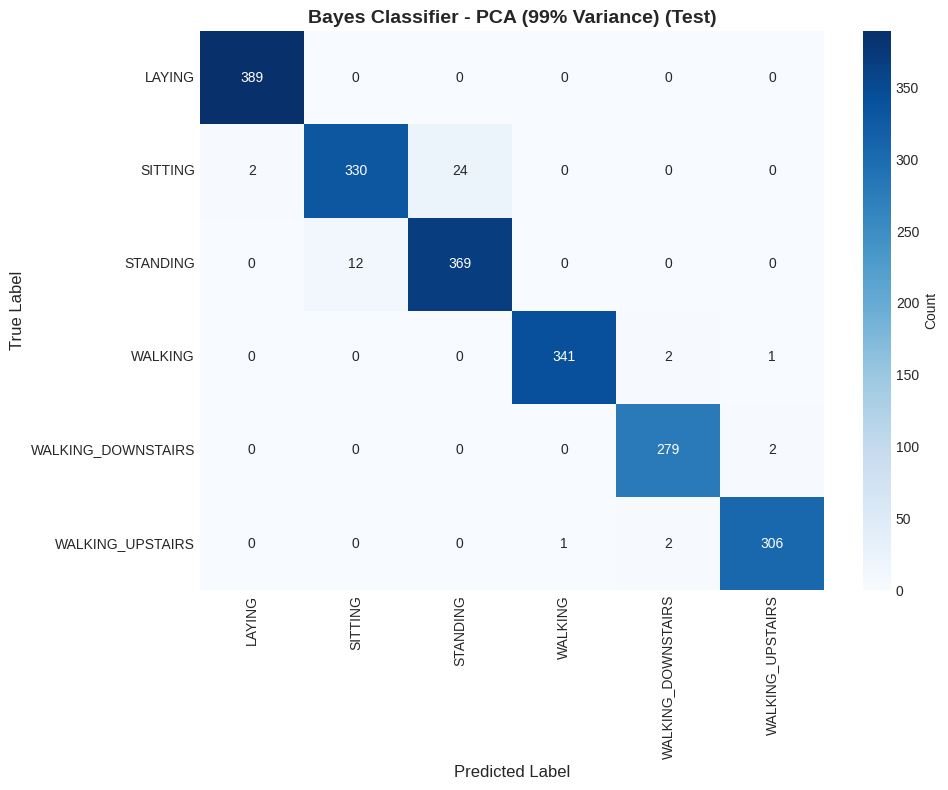


--- Validation Set Metrics ---
Accuracy: 0.9718
Precision (Macro): 0.9722
Precision (Micro): 0.9718
Recall (Macro): 0.9728
Recall (Micro): 0.9718
F1-Score (Macro): 0.9724
F1-Score (Micro): 0.9718

--- Test Set Metrics ---
Accuracy: 0.9777
Precision (Macro): 0.9787
Precision (Micro): 0.9777
Recall (Macro): 0.9783
Recall (Micro): 0.9777
F1-Score (Macro): 0.9784
F1-Score (Micro): 0.9777


In [29]:
# 4. Bayes classifier on PCA (99% variance)

bayes_pca99_val, bayes_pca99_test, bayes_pca99_model = train_and_evaluate_bayes(
    'Activity_PCA99_Train.csv',
    'Activity_PCA99_Validation.csv',
    'Activity_PCA99_Test.csv',
    'PCA (99% Variance)'
)